# <span style="color:blue"> Final Project </span>

Project Name: Pit Stop Strategies 

Members: Jiuyi (Joy) Cheng, Alice Li, Sharon Li, Caroline Zu

### Introduction


A markdown text with 1-2 paragraphs that summarize the main goals of the
project. Imagine you are giving a report to someone who is not your professor.
The first paragraph should briefly describe what the topic is, what data analysis
question you’re interested in, and why it is relevant. The introduction should end
with a high-level description of the results and the coming structure of the
project. Try to make the text self-contained, intended for someone who isn’t
familiar with Formula 1/FIFA/NFL/U.S. politics/other topic or the dataset being
used. 

In [9]:
# Import relevant libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

Research Question: pit stop 

Guiding Question 


Formula One

### Data Description

Write a markdown chunk of 1 paragraph describing which dataset tables (among the multiple options) you will be using. State what each row represents, how many observations are contained in each table, and a brief overview of the of
the data that is contained there:

▪ Import any necessary libraries.
▪ Import the data.
▪ Do any calculations for counting the number of rows, etc.


Do pit stop strategies impact race outcomes, and which drivers are consistently helped or hurt by them? 

Guiding questions: 
Fans think pit stops win races — let’s measure whether this belief is real, consistently biased, or overstated.

Sub-Questions: 
How does average pit stop duration correlate with position changes from grid to finish?

Which drivers benefit the most from pit stop timing (position gained immediately after)?

Are constructors systematically better or worse at pit stops across seasons?


Data Used: pit_stops, results, driver, constructor
Fun Angle: Who’s sabotaged by the crew? 

In [6]:
import pandas as pd

df_circuits = pd.read_csv("1-Formula_One/circuits.csv")
# display(df_circuits.head())
print("circuits")
display(df_circuits.columns)

df_constructor_results = pd.read_csv("1-Formula_One/constructor_results.csv")
print("constructor results")
# display(df_constructor_results.head())
display(df_constructor_results.columns)

df_constructor_standings = pd.read_csv("1-Formula_One/constructor_standings.csv")
# display(df_constructor_standings.head())
print("constructor standings")
display(df_constructor_standings.columns)


df_constructors = pd.read_csv("1-Formula_One/constructors.csv")
# display(df_constructors.head())
print("constructors")
display(df_constructors.columns)


df_driver_standings = pd.read_csv("1-Formula_One/driver_standings.csv")
# display(df_driver_standings.head())
print("driver standings")
display(df_driver_standings.columns)


df_drivers = pd.read_csv("1-Formula_One/drivers.csv")
# display(df_drivers.head())
print("drivers")
display(df_drivers.columns)


df_lap_times = pd.read_csv("1-Formula_One/lap_times.csv")
# display(df_lap_times.head())
print("lap times")
display(df_lap_times.columns)


df_pit_stops = pd.read_csv("1-Formula_One/pit_stops.csv")
# display(df_pit_stops.head())
print("pit stops")
display(df_pit_stops.columns)


df_qualifying = pd.read_csv("1-Formula_One/qualifying.csv")
# display(df_qualifying.head())
print("qualifying")
display(df_qualifying.columns)


df_races = pd.read_csv("1-Formula_One/races.csv")
# display(df_races.head())
print("races")
display(df_races.columns)


df_results = pd.read_csv("1-Formula_One/results.csv")
# display(df_results.head())
print("results")
display(df_results.columns)


df_seasons = pd.read_csv("1-Formula_One/seasons.csv")
# display(df_seasons.head())
print("seasons")
display(df_seasons.columns)


df_sprint_results = pd.read_csv("1-Formula_One/sprint_results.csv")
# display(df_sprint_results.head())
print("sprint results")
display(df_sprint_results.columns)


df_status = pd.read_csv("1-Formula_One/status.csv")
# display(df_status.head())
print("status")
display(df_status.columns)

circuits


Index(['circuitId', 'circuitRef', 'name', 'location', 'country', 'lat', 'lng',
       'alt', 'url'],
      dtype='object')

constructor results


Index(['constructorResultsId', 'raceId', 'constructorId', 'points', 'status'], dtype='object')

constructor standings


...

Index(['year', 'url'], dtype='object')

sprint results


Index(['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid',
       'position', 'positionText', 'positionOrder', 'points', 'laps', 'time',
       'milliseconds', 'fastestLap', 'fastestLapTime', 'statusId'],
      dtype='object')

status


Index(['statusId', 'status'], dtype='object')

In [7]:
# Total pit stops and average duration
pit_summary = df_pit_stops.groupby(['raceId', 'driverId']).agg(
    pit_count=('stop', 'count'),
    avg_pit_duration=('milliseconds', 'mean')
).reset_index()

# Merge with results
df = df_results.merge(pit_summary, on=['raceId', 'driverId'], how='left')

# Fill missing pit data (e.g., no pit stop)
df['pit_count'] = df['pit_count'].fillna(0)
df['avg_pit_duration'] = df['avg_pit_duration'].fillna(0)

# Merge driver info (optional)
df = df.merge(df_drivers[['driverId', 'forename', 'surname']], on='driverId', how='left')


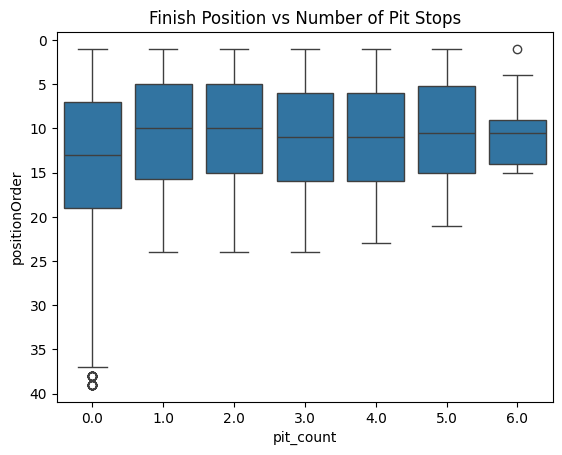

In [11]:
# Pit stops vs finish position
sns.boxplot(x='pit_count', y='positionOrder', data=df)
plt.title("Finish Position vs Number of Pit Stops")
plt.gca().invert_yaxis()  # 1st place at top
plt.show()


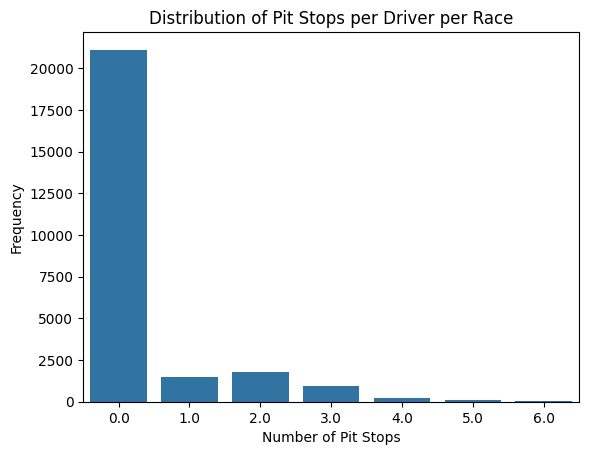

In [13]:
sns.countplot(x='pit_count', data=df)
plt.title("Distribution of Pit Stops per Driver per Race")
plt.xlabel("Number of Pit Stops")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Duration vs finish position
sns.scatterplot(x='avg_pit_duration', y='positionOrder', hue='forename', data=df)
plt.gca().invert_yaxis()
plt.show()

sns.scatterplot(x='avg_pit_duration', y='positionOrder', hue='surname', data=df, alpha=0.7)
plt.title("Finish Position vs Average Pit Stop Duration")
plt.gca().invert_yaxis()
plt.show()

In [12]:
model = smf.ols(
    "positionOrder ~ pit_count + avg_pit_duration + grid", 
    data=df
).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          positionOrder   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                     342.6
Date:                Mon, 17 Nov 2025   Prob (F-statistic):          3.82e-218
Time:                        12:02:50   Log-Likelihood:                -88356.
No. Observations:               25660   AIC:                         1.767e+05
Df Residuals:                   25656   BIC:                         1.768e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           11.4725      0.089  

In [ ]:
df['predicted'] = model.predict(df.reset_index())
df['residual'] = df['predicted'] - df['positionOrder']

driver_effects = df.groupby('driverId')['residual'].mean().sort_values()
driver_effects = driver_effects.reset_index().merge(df_drivers[['driverId', 'forename', 'surname']], on='driverId')
print(driver_effects.head(10))  # Most helped
print(driver_effects.tail(10))  # Most hurt

   driverId   residual forename       surname
0       134 -27.360854   Enrico     Bertaggia
1       492 -26.527521   Menato         Boffa
2       164 -25.098949  Joachim    Winkelhock
3       266 -23.527521    Brian       McGuire
4       161 -23.227521   Volker       Weidler
5       150 -23.027521     Gary       Brabham
6       760 -22.527521    Piero         Dusio
7       142 -22.142905    Pedro        Chaves
8       263 -22.027521    Mikko  Kozarowitzky
9       149 -21.527521  Claudio        Langes
     driverId   residual forename   surname
844       448   7.863081    Peter   Broeker
845       801   7.894338  Charles     Pozzi
846       794   7.925594     Joie  Chitwood
847       743   7.925594     Eric  Thompson
848       695   7.925594    Oscar    Gálvez
849       662   8.185995     Mike   Sparken
850       767   8.347453     Carl   Forberg
851       766   9.990695      Lee   Wallard
852       802  10.441223   Dorino  Serafini
853       591  13.508910   George     Amick


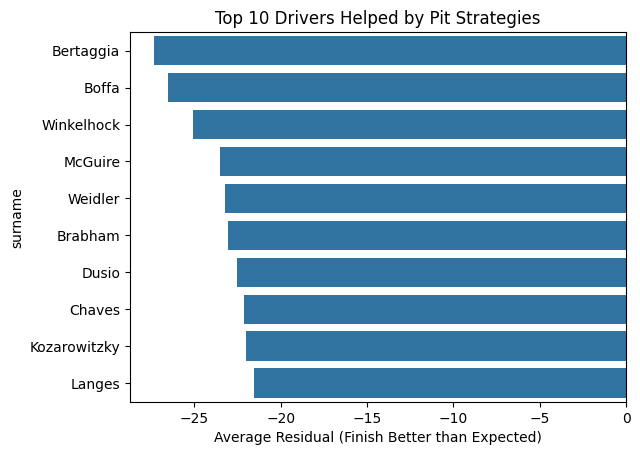

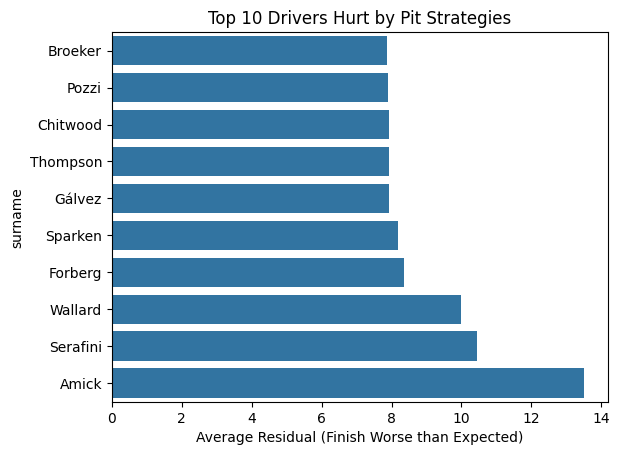

In [18]:
# Create top 10 helped/hurt drivers
top_helped = driver_effects.head(10)
top_hurt = driver_effects.tail(10)

sns.barplot(x='residual', y='surname', data=top_helped)
plt.title("Top 10 Drivers Helped by Pit Strategies")
plt.xlabel("Average Residual (Finish Better than Expected)")
plt.show()

sns.barplot(x='residual', y='surname', data=top_hurt)
plt.title("Top 10 Drivers Hurt by Pit Strategies")
plt.xlabel("Average Residual (Finish Worse than Expected)")
plt.show()

Positive residual → finishes better than predicted (pit stops helped).

Negative residual → finishes worse than predicted (pit stops hurt).

In [20]:
sns.scatterplot(x='lap', y='positionOrder', hue='pit_count', size='avg_pit_duration', data=df_pit_stops.merge(df_results, on=['raceId','driverId']), alpha=0.7)
plt.gca().invert_yaxis()
plt.title("Pit Stop Timing vs Finish Position")
plt.xlabel("Lap Number of Pit Stop")
plt.ylabel("Finish Position")
plt.show()

ValueError: Could not interpret value `pit_count` for `hue`. An entry with this name does not appear in `data`.

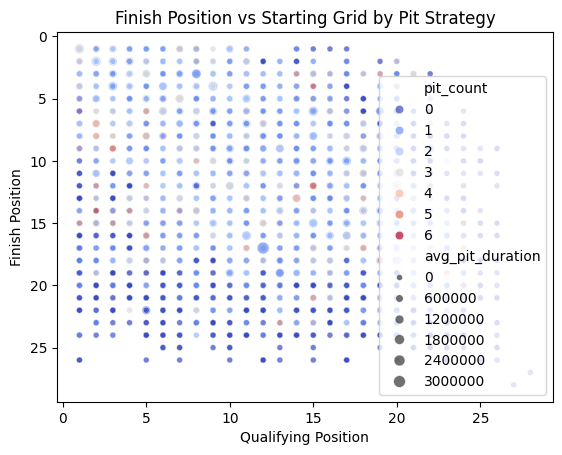

In [24]:
qualifying_info = df_qualifying[['raceId','driverId','position']].rename(columns={'position':'qualifying_position'})
df_q = df.merge(qualifying_info, on=['raceId','driverId'], how='left')

sns.scatterplot(
    x='qualifying_position',
    y='positionOrder',
    hue='pit_count',
    size='avg_pit_duration',
    data=df_q,
    palette='coolwarm',
    alpha=0.7
)
plt.gca().invert_yaxis()
plt.title("Finish Position vs Starting Grid by Pit Strategy")
plt.xlabel("Qualifying Position")
plt.ylabel("Finish Position")
plt.show()

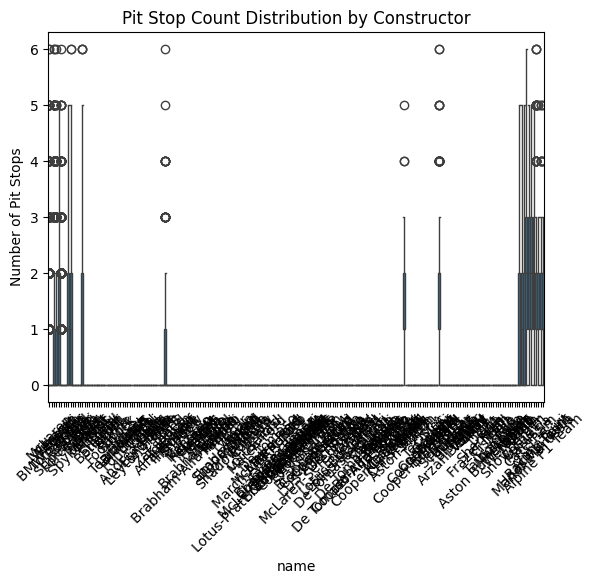

In [28]:
df_team = df.merge(df_constructors[['constructorId','name']], on='constructorId')

sns.boxplot(x='name', y='pit_count', data=df_team)
plt.xticks(rotation=45)
plt.title("Pit Stop Count Distribution by Constructor")
plt.ylabel("Number of Pit Stops")
plt.show()

In [30]:
driver_standings_info = df_driver_standings[['driverId','points','position']].rename(columns={'position':'season_position'})
df_eff = df.merge(driver_standings_info, on='driverId', how='left')

sns.scatterplot(
    x='avg_pit_duration',
    y='positionOrder',
    hue='season_position',
    size='points', 
    palette='viridis',
    data=df_eff,
    alpha=0.7
)
plt.gca().invert_yaxis()
plt.title("Pit Stop Duration vs Finish Position (Colored by Season Standing)")
plt.show()

ValueError: Could not interpret value `points` for `size`. An entry with this name does not appear in `data`.

In [ ]:
lap_data = df_lap_times.merge(df_pit_stops, on=['raceId','driverId'], how='left')

sns.lineplot(x='lap', y='position', hue='driverId', data=lap_data.sample(1000), alpha=0.7)
plt.gca().invert_yaxis()
plt.title("Position Trajectories Across Laps (Sampled Drivers)")
plt.xlabel("Lap Number")
plt.ylabel("Position")
plt.show()

ValueError: Could not interpret value `lap` for `x`. An entry with this name does not appear in `data`.

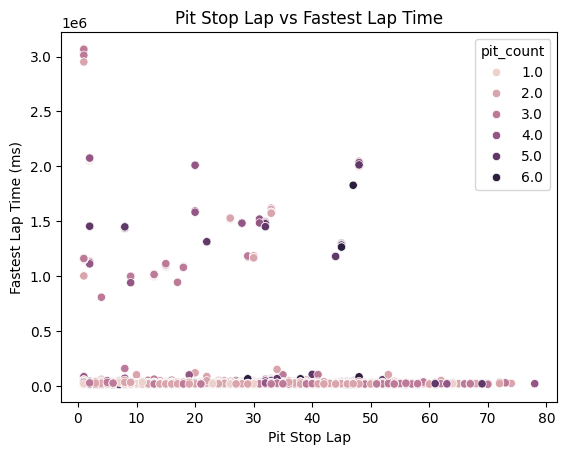

In [33]:
fastest_lap = df_lap_times.groupby(['raceId','driverId'])['milliseconds'].min().reset_index()
df_fl = df.merge(fastest_lap, on=['raceId','driverId'])
sns.scatterplot(x='lap', y='milliseconds', hue='pit_count', data=df_pit_stops.merge(df_fl, on=['raceId','driverId']))
plt.title("Pit Stop Lap vs Fastest Lap Time")
plt.xlabel("Pit Stop Lap")
plt.ylabel("Fastest Lap Time (ms)")
plt.show()

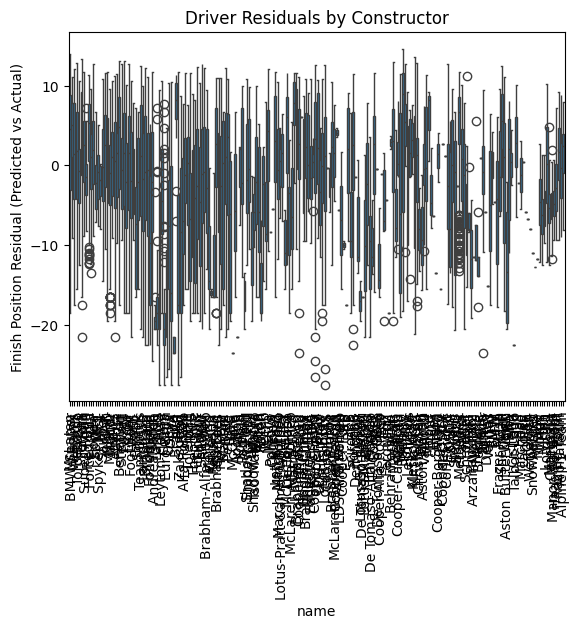

In [ ]:
# Not true 
sns.boxplot(x='name', y='residual', data=df_team)
plt.xticks(rotation=90)
plt.title("Driver Residuals by Constructor")
plt.ylabel("Finish Position Residual (Predicted vs Actual)")
plt.show()


o Write a paragraph in markdown describing any merging procedures:
▪ Include code for merging.
o Write a paragraph in markdown summarizing data cleaning procedures:
▪ Include code for data cleaning.
o Write a paragraph describing your main columns:
▪ Compute a table of descriptive statistics for the main columns of the
merged dataset that you’re interested. Try to be selective. The idea is to
do a deeper analysis of a few columns rather than to do a lot.


### Results 

o This should contain a combination of code to produce tables/plots and
markdown text explaining what the findings are.
o Be creative! The idea is to understand the relationship between different sets of
columns to answer an interesting question about the data.

### Discussion:

Provide a brief 1 paragraph markdown chunk summarizing your findings.
Describe the main things you learned from the data.